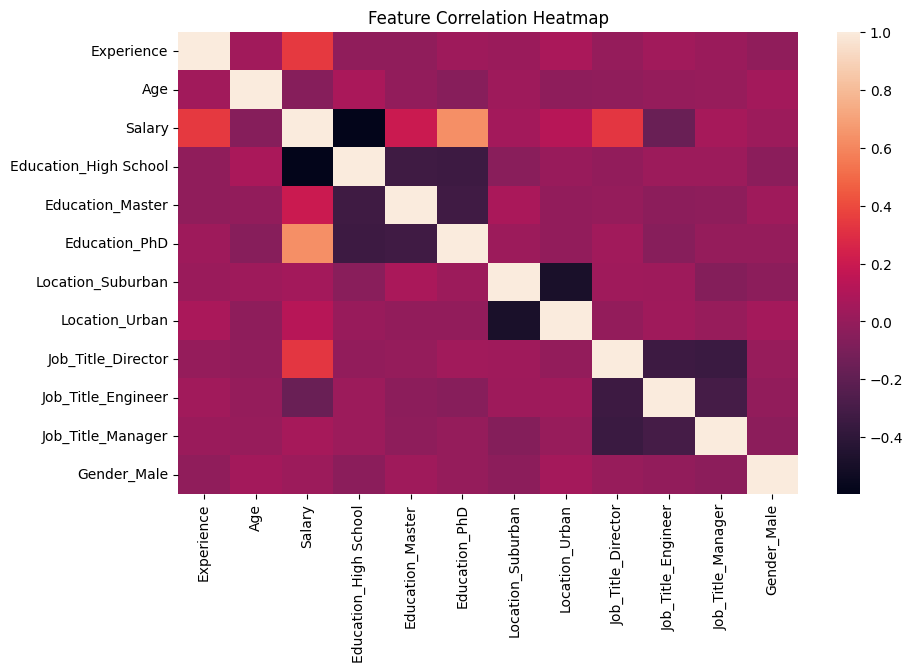

R2 Score: 0.834105173067016
Mean Squared Error: 135457531.6089418
Training data shape: (800, 11)
Feature names: Index(['Experience', 'Age', 'Education_High School', 'Education_Master',
       'Education_PhD', 'Location_Suburban', 'Location_Urban',
       'Job_Title_Director', 'Job_Title_Engineer', 'Job_Title_Manager',
       'Gender_Male'],
      dtype='object')
Sample predictions: [ 79079.97900483  58954.49534242 103361.80873632  96700.83287064
  95599.83991555]


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


df = pd.read_csv("salary_prediction_data.csv")


df = df.dropna()


categorical_cols = df.select_dtypes(include="object").columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


X = df.drop("Salary", axis=1)
y = df["Salary"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)


pred = model.predict(X_test)


print("R2 Score:", r2_score(y_test, pred))
print("Mean Squared Error:", mean_squared_error(y_test, pred))


print("Training data shape:", X_train.shape)
print("Feature names:", X_train.columns)
print("Sample predictions:", pred[:5])
